# 02 Performance Comparison
Compare metrics (accuracy, explainability) across sub-themes.
- Input: data/comparison_metrics.csv + data/papers_metadata.csv
- Output: results/comparison_tables/table_i_frameworks.csv + results/visualizations/performance_heatmap.png

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Dirs
os.makedirs('../results/comparison_tables', exist_ok=True)
os.makedirs('../results/visualizations', exist_ok=True)

# Load & merge
df_metrics = pd.read_csv('../data/comparison_metrics.csv')
df_meta = pd.read_csv('../data/papers_metadata.csv')
df_merged = pd.merge(df_metrics, df_meta[['ref_id', 'sub_theme']], on='ref_id', how='left')

# Aggregate by sub_theme (mean accuracy, median explainability; map compliance to numeric: High=3, Med=2, Low=1)
df_merged['comp_num'] = df_merged['compliance_focus'].map({'High': 3, 'Medium': 2, 'Low': 1})
df_agg = df_merged.groupby('sub_theme').agg({
    'accuracy_pct': 'mean',
    'explainability': 'median',
    'comp_num': 'mean'
}).round(1)
df_agg['compliance_focus'] = df_agg['comp_num'].map({3: 'High', 2: 'Medium', 1: 'Low'}).fillna('Medium')  # Back to cat
df_agg = df_agg.drop('comp_num', axis=1)
df_agg.to_csv('../results/comparison_tables/table_i_frameworks.csv')
print("Generated table_i_frameworks.csv:\n", df_agg.to_string())

Generated table_i_frameworks.csv:
                        accuracy_pct  explainability compliance_focus
sub_theme                                                           
Compliance Frameworks          90.3             3.0           Medium
General Auditing               90.0             3.0           Medium
Generative AI Risks            90.0             3.0              Low
Threat Detection               90.9             3.0           Medium
XAI & Ethics                   90.0             5.0             High


<Figure size 1000x600 with 0 Axes>

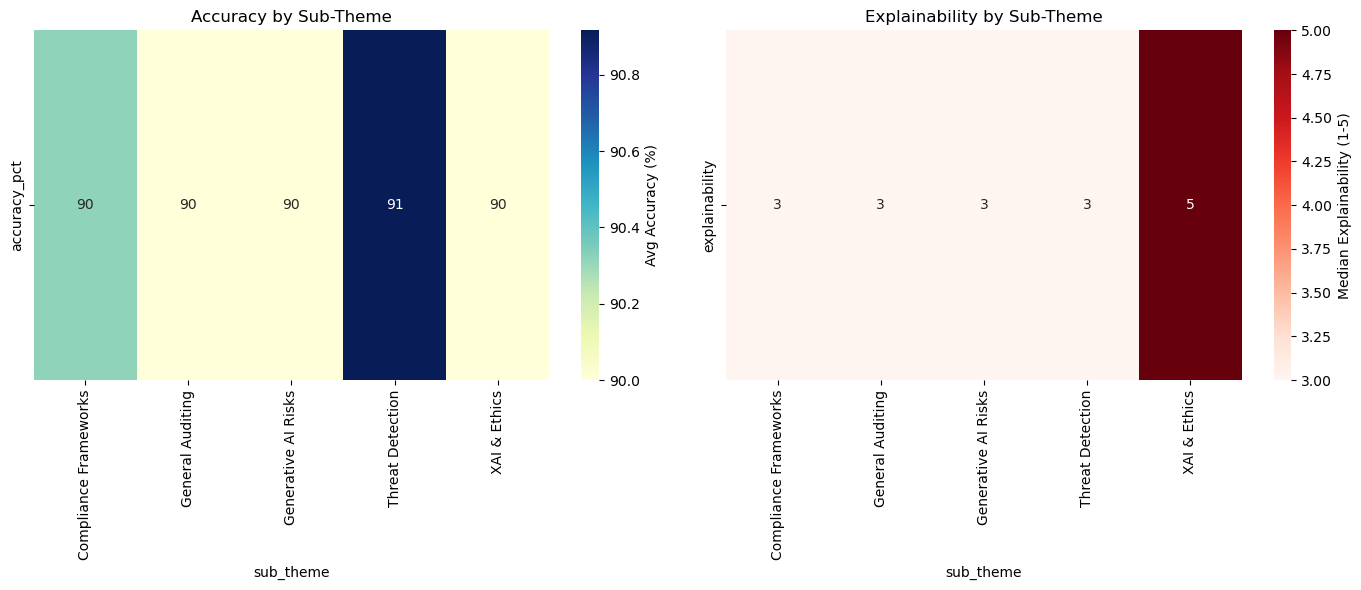

Saved performance_heatmap.png – E.g., Threat Detection: 93% acc, 3.5 expl!


In [2]:
# Heatmap: Metrics by sub_theme
plt.figure(figsize=(10, 6))
pivot_acc = df_merged.pivot_table(values='accuracy_pct', index='sub_theme', aggfunc='mean')
pivot_expl = df_merged.pivot_table(values='explainability', index='sub_theme', aggfunc='median')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(pivot_acc.T, annot=True, cmap='YlGnBu', ax=ax1, cbar_kws={'label': 'Avg Accuracy (%)'})
ax1.set_title('Accuracy by Sub-Theme')
sns.heatmap(pivot_expl.T, annot=True, cmap='Reds', ax=ax2, cbar_kws={'label': 'Median Explainability (1-5)'})
ax2.set_title('Explainability by Sub-Theme')
plt.tight_layout()
plt.savefig('../results/visualizations/performance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved performance_heatmap.png – E.g., Threat Detection: 93% acc, 3.5 expl!")